# Modelling Minecraft Speedrun dataset
- In deze notebook ga ik aan de slag met het opstellen van een Model van de Minecraft Speedrunning Dataset

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Load dataset
data = pd.read_csv('mce.csv')

# Preprocess data
data.fillna(method='ffill', inplace=True)

# Create a target variable - for example, predict if a run is in top 3 places
data['target'] = (data['place'] <= 3).astype(int)

# Select relevant numeric features and encode categorical ones
# For now, let's use simple features
features = ['speedrun_time', 'is_verified', 'platform_released_year']
X = data[features].copy()

# Convert boolean to int if needed
if 'is_verified' in X.columns:
    X['is_verified'] = X['is_verified'].astype(int)

y = data['target']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       652
           1       1.00      0.40      0.57        10

    accuracy                           0.99       662
   macro avg       1.00      0.70      0.78       662
weighted avg       0.99      0.99      0.99       662



/var/folders/43/d1ll8jk93n93d7g8f56tk8qh0000gn/T/ipykernel_89646/3048239726.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [29]:
# Explore the dataset structure
print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())
print("\nFirst few rows:")
data.head()

Dataset shape: (3307, 25)

Column names:
['run_id', 'player_id', 'place', 'speedrun_time', 'is_verified', 'verify_date', 'submitted_date', 'examiner_id', 'timing_type', 'platform_id', 'platform_name', 'platform_released_year', 'is_level_cat', 'level_id', 'level_name', 'level_rules', 'game_id', 'category_id', 'cat_name', 'cat_rules', 'player_name', 'player_country', 'player_pronouns', 'player_signup_date', 'target']

First few rows:


,run_id,player_id,place,speedrun_time,is_verified,verify_date,submitted_date,examiner_id,timing_type,platform_id,...,level_rules,game_id,category_id,cat_name,cat_rules,player_name,player_country,player_pronouns,player_signup_date,target
0,zp2g6d8y,xz995g08,1,98.0,True,2022-01-30 20:40:44,2022-01-30 15:22:28,v8le49vx,realtime,nzelkr6q,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,Khalooody,bh,NaN,2020-01-04 11:41:15,1
1,y6oovepy,x7qey508,2,100.0,True,2023-02-15 05:17:52,2023-02-13 01:47:28,xz995g08,realtime,nzelkr6q,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,jerrinth3glitch,us,She/Her,2020-07-05 03:44:10,1
2,z0ojvx8z,xkoo9n28,3,103.0,True,2022-02-08 01:32:46,2022-02-06 02:03:06,xk4o37kj,realtime,7m6ylw9p,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,TrenttheN642,us,She/Her,2020-01-18 17:58:36,1
3,y88133ny,8vk99p5j,3,103.0,True,2022-04-21 18:02:43,2022-04-20 08:45:25,xk4o37kj,realtime,nzelkr6q,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,_Shrub,sa,She/Her,2021-02-24 16:37:31,1
4,zp99wpgm,xz995g08,5,106.0,True,2022-05-30 20:47:53,2022-05-30 18:41:16,v8le49vx,realtime,8gejn93d,...,NaN,mce,zd3vpoe2,Set Seed Any%,## Set Seed Any%\r\nReach the End Poem as quic...,Khalooody,bh,She/Her,2020-01-04 11:41:15,0


# Opdracht 1 - Training the model

In [30]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_y_pred = dt_model.predict(X_test)
print(classification_report(y_test, dt_y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       652
           1       1.00      0.40      0.57        10

    accuracy                           0.99       662
   macro avg       1.00      0.70      0.78       662
weighted avg       0.99      0.99      0.99       662



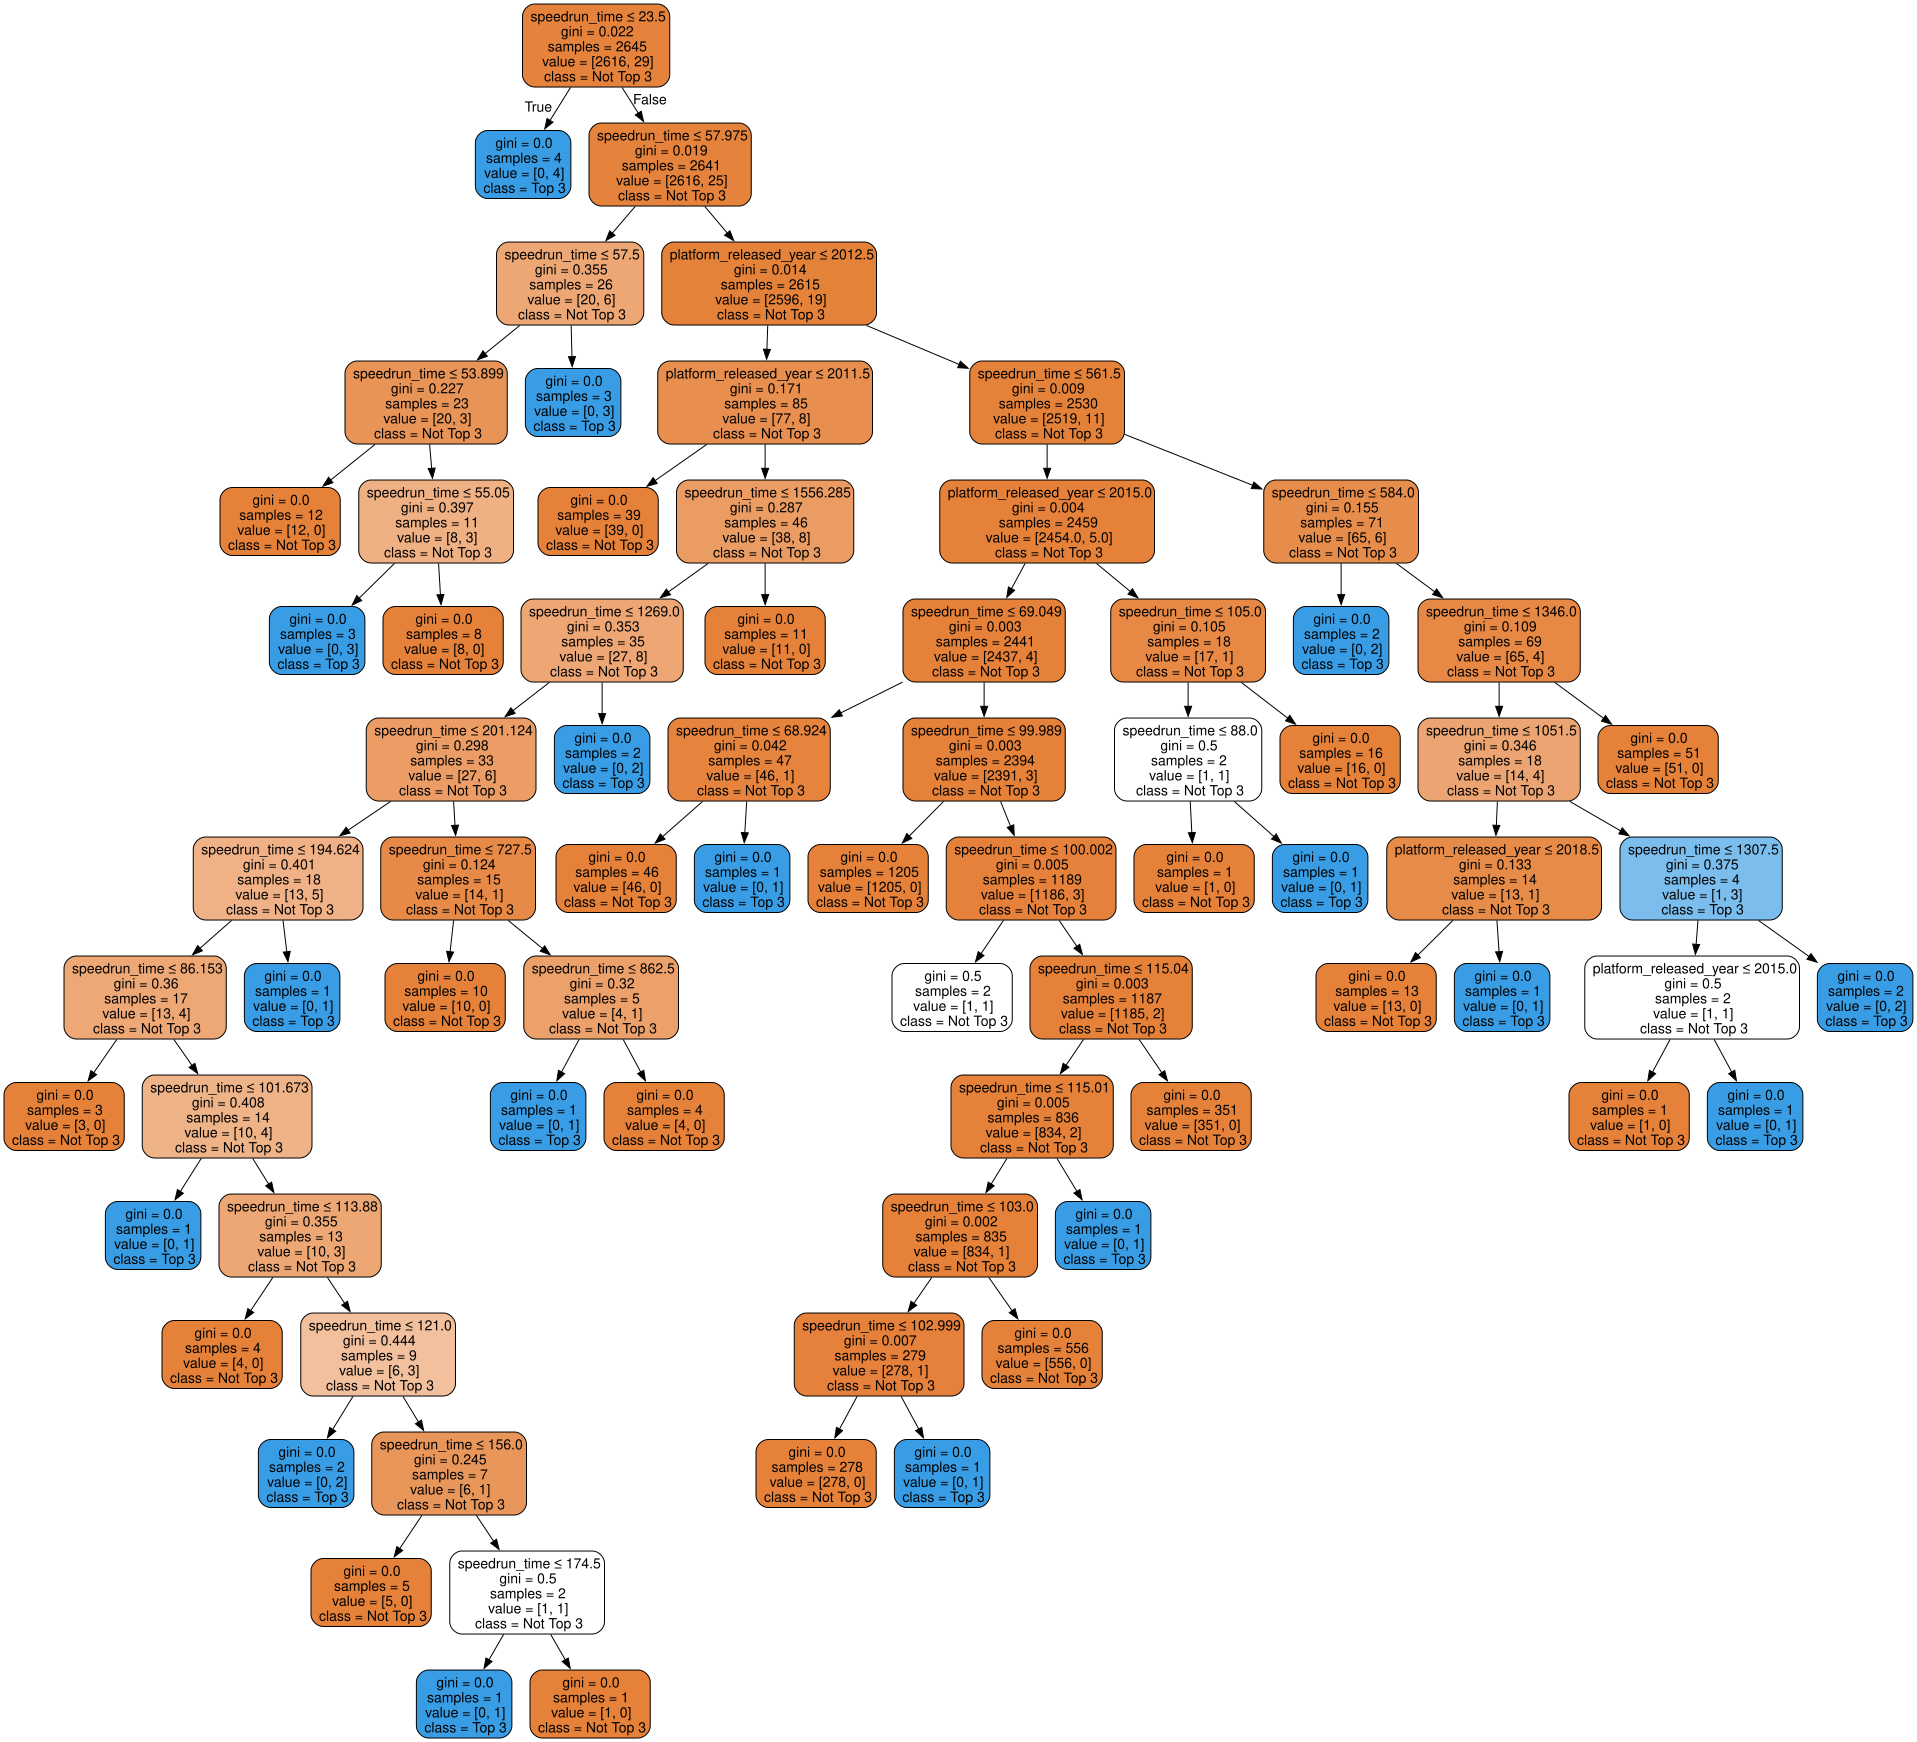

In [ ]:
from sklearn import tree
import graphviz
from sklearn.tree import export_graphviz

# Visualize the decision tree
dot_data = export_graphviz(dt_model, out_file=None, 
                           feature_names=features,  
                           class_names=['Not Top 3', 'Top 3'],  
                           filled=True, rounded=True,  
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves the tree as a PDF file
graph  # Display the tree in the notebook

Creating a visual